# EV Risk Scoring Model

## Section 1: Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot") 
np.random.seed(42)

risk_matrix=pd.read_excel("Week3_EV_RiskFactorMatrix_Group_B.xlsx", skiprows=3)
risk_matrix=risk_matrix.dropna(subset=["Risk Factor"])
risk_matrix.head()


,#,Risk Factor,Category,Description / Driver,"Probability\n(1=Low, 5=High)","Severity\n(1=Low, 5=High)",Risk Score\n(P × S),Risk Level,Proposed\nLoading %,Key Data Source,Underwriting Action
1,1,Thermal Runaway — NMC/NCA Chemistry,Battery,NMC/NCA cells release ~300 kJ/Ah on failure vs...,4.0,5.0,20.0,CRITICAL,30–45%,NFPA 855; NHTSA SGO 2021-01; Week 2 Memo S2,Apply NMC/NCA surcharge; require fire suppress...
2,2,Thermal Runaway — LFP Chemistry,Battery,LFP thermal onset at 270°C vs 210°C (NMC); sig...,2.0,4.0,8.0,MEDIUM,10–18%,NFPA 855; BYD Atto 3 spec sheet; Week 2 Memo S1,Base loading; LFP discount vs NMC baseline
3,3,Battery Degradation & Capacity Loss,Battery,LFP retains ~80% capacity at 150k km; NMC degr...,3.0,3.0,9.0,MEDIUM,8–15%,MIT Battery Lab 2023; Tesla Battery Report 2024,Require annual battery health cert after Year ...
4,4,Battery Management System (BMS) Failure,Battery,"BMS failure can allow overcharge, cell imbalan...",2.0,5.0,10.0,HIGH,15–25%,NHTSA complaints EV database; OEM recall notices,Exclusion clause for non-OEM BMS modifications...
5,5,Battery Flood / Water Ingress,Battery,Malaysia's monsoon season creates elevated flo...,4.0,4.0,16.0,HIGH,20–30%,PICC China flood data 2020; Malaysia flood sta...,Flood zone surcharge; require IP67/IP68 batter...


In [2]:
fleet_mix = {
    "BYD_Atto3_LFP": 0.32,
    "Tesla_M3_NMC": 0.18, # 18% Tesla Model 3 LR (NMC)
    "Tesla_M3_NCA": 0.06, # 6% Tesla Model 3 Performance (NCA)
    "Hyundai_Ioniq5": 0.12, # 12% Hyundai Ioniq 5 (NMC)
    "BMW_iX": 0.05, # 5% BMW iX (NMC)
    "Other_BEV": 0.27 # 27% other models
}

N=10000
vehicles=np.random.choice(list(fleet_mix.keys()),size=N,p=list(fleet_mix.values()))

chemistry_map = {
    "BYD_Atto3_LFP": "LFP",
    "Tesla_M3_NMC": "NMC", 
    "Tesla_M3_NCA": "NCA", 
    "Hyundai_Ioniq5": "NMC", 
    "BMW_iX": "NMC", 
    "Other_BEV": "NMC" 
}

si_map = {
    "BYD_Atto3_LFP": (130000, 160000),
    "Tesla_M3_NMC": (185000, 215000),
    "Tesla_M3_NCA": (225000, 250000),
    "Hyundai_Ioniq5":(175000, 210000),
    "BMW_iX": (440000, 550000),
    "Other_BEV": (90000, 160000)    
}

adas_map = {
    'BYD_Atto3_LFP': 'BYD_DiPilot',
    'Tesla_M3_NMC': 'Tesla_Autopilot',
    'Tesla_M3_NCA': 'Tesla_Autopilot',
    'Hyundai_Ioniq5': 'Level1',
    'BMW_iX': 'Level1',
    'Other_BEV': 'None'
}

## Section 2: Exploratory Data Analysis

In [3]:
risk_matrix["Category"].value_counts()

Category
Battery           8
ADAS              7
Repair Cost       5
Environmental     5
Residual Value    4
Infrastructure    4
Name: count, dtype: int64

In [4]:
risk_matrix["Risk Score\n(P × S)"].describe()

count    33.000000
mean     11.484848
std       4.458988
min       4.000000
25%       9.000000
50%      12.000000
75%      15.000000
max      20.000000
Name: Risk Score\n(P × S), dtype: float64

<Axes: >

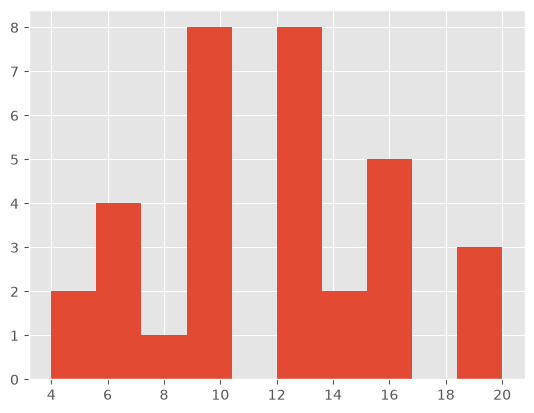

In [5]:
risk_matrix["Risk Score\n(P × S)"].hist()

## Section 3: Risk Factor Definition and Weighing

In [6]:
risk_lookup=dict(zip(risk_matrix["Risk Factor"],risk_matrix["Risk Score\n(P × S)"]))

In [7]:
df=pd.DataFrame({
    "vehicle_type":vehicles,
    "battery_chemistry":[chemistry_map[v] for v in vehicles],
    "adas_level":[adas_map[v] for v in vehicles],
    "driver_age": np.random.normal(38,10,N).clip(18,75).astype(int),
    "ev_experience_years": np.random.choice([0,1,2,3], N, p=[0.3,0.35,0.25,0.1]),
    "garaging": np.random.choice(["basement","covered","open"], N, p=[0.25,0.35,0.40]),
    "state": np.random.choice(["Selangor","KL","Johor","Penang","Other"], N, p=[0.30,0.15,0.15,0.10,0.30]),
    "annual_km": np.random.normal(18000,6000, N).clip(5000,60000),
    "sum_insured": [np.random.randint(*si_map[v]) for v in vehicles]
})
df

,vehicle_type,battery_chemistry,adas_level,driver_age,ev_experience_years,garaging,state,annual_km,sum_insured
0,Tesla_M3_NMC,NMC,Tesla_Autopilot,23,0,covered,Penang,21876.018565,214829
1,Other_BEV,NMC,None,26,0,open,Johor,26017.402202,135911
2,Other_BEV,NMC,None,41,0,open,KL,25533.216072,99428
3,Hyundai_Ioniq5,NMC,Level1,26,0,open,Other,12598.874254,202256
4,BYD_Atto3_LFP,LFP,BYD_DiPilot,49,1,covered,Penang,13527.501305,156849
...,...,...,...,...,...,...,...,...,...
9995,Other_BEV,NMC,None,37,1,open,KL,12893.104994,145943
9996,Other_BEV,NMC,None,45,1,open,Other,5157.596651,110585
9997,Other_BEV,NMC,None,47,3,basement,Selangor,29854.581943,120312
9998,Tesla_M3_NMC,NMC,Tesla_Autopilot,31,1,open,Other,7788.861218,213820


In [8]:
battery_risk = {
    "LFP": 8,
    "NMC": 20,
    "NCA": 20
}

adas_risk = {
    "None": 0,
    "Level1": 4,
    "BYD_DiPilot": 9,
    "Tesla_Autopilot": 16
}

state_risk = {
    "KL": 5,
    "Penang": 8,
    "Selangor": 10,
    "Other": 10,
    "Johor": 16
}

def km_risk(km):
    if km < 10000:
        return 4
    elif km < 20000:
        return 8
    elif km < 30000:
        return 12
    else:
        return 16

## Section 4: Risk Score Calculator

array([[<Axes: title={'center': 'driver_age'}>,
        <Axes: title={'center': 'ev_experience_years'}>,
        <Axes: title={'center': 'annual_km'}>],
       [<Axes: title={'center': 'sum_insured'}>,
        <Axes: title={'center': 'risk_score'}>,
        <Axes: title={'center': 'claim_probability'}>],
       [<Axes: title={'center': 'had_claim'}>, <Axes: >, <Axes: >]],
      dtype=object)

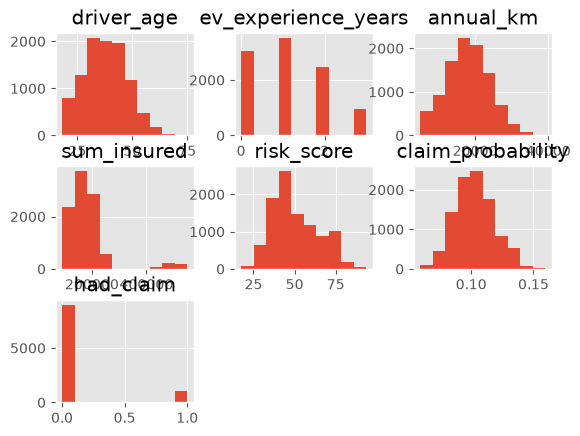

In [14]:
def calculate_ev_risk_score(row):

    score = 0

    score += battery_risk[row["battery_chemistry"]]
    score += state_risk[row["state"]]
    score += km_risk(row["annual_km"])
    score += adas_risk[row["adas_level"]]

    if row["driver_age"] < 25:
        score += 10
    elif row["driver_age"] > 55:
        score += 4
    else:
        score += 6

    if row["ev_experience_years"] == 0:
        score += 10
    elif row["ev_experience_years"] == 1:
        score += 8
    elif row["ev_experience_years"] == 2:
        score += 6
    else:
        score += 4

    return ((score-25)/63)*100

df["risk_score"]=df.apply(calculate_ev_risk_score, axis=1)
def risk_band(score):
    if score<43:
        return "low"
    elif score<67:
        return "medium"
    else:
        return "high"
    
df["risk_band"]=df["risk_score"].apply(risk_band)
df.hist()

## Section 5: Sensitivity Analysis

## Section 6: Synthetic Scenario Testing

In [15]:
base_freq=0.095
chem_freq = {
    'LFP': 0.85,
    'NMC': 1.00,
    'NCA': 1.00
}
garage_freq = {
    'basement': 1.10,
    'covered': 1.00,
    'open': 0.90
}
age_freq = df['driver_age'].apply(
    lambda a: 1.15 if a < 25
    else (0.95 if a > 55 else 1.00)
)
exp_freq = df['ev_experience_years'].map({
    0: 1.15,
    1: 1.08,
    2: 1.00,
    3: 0.95
})
km_freq = df['annual_km'].apply(
    lambda km: 0.90 if km < 10000
    else (1.00 if km < 20000
    else (1.10 if km < 30000
    else 1.20))
)
state_freq = {
    'KL': 0.95,
    'Penang': 1.00,
    'Selangor': 1.05,
    'Other': 1.05,
    'Johor': 1.10
}
df["claim_probability"]=((base_freq)*df["battery_chemistry"].map(chem_freq)*df["garaging"].map(garage_freq)* df['state'].map(state_freq)*age_freq.values* exp_freq.values* km_freq.values).clip(0.01, 0.40)
df["had_claim"]=np.random.binomial(1,df["claim_probability"])
df["risk_band"].value_counts()

risk_band
medium    4571
low       3748
high      1681
Name: count, dtype: int64

## Section 7: Bayesian Update Demonstration

## Section 8: Conclusions